In [41]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pygraphviz import AGraph

In [2]:
methods = [
    {
        'name': 'vgg',
        'model': 'VGG16',
    },
    {
        'name': 'resnet',
        'model': 'ResNet18',
    },
    {
        'name': 'resnet_sigmoid',
        'model': 'ResNet18 (Sigmoid)',
    },
    {
        'name': 'vqa',
        'model': 'VQA',
    },
    {
        'name': 'svm',
        'model': 'SVM',
    },
    {
        'name': 'log_reg',
        'model': 'Logistic Regression',
    },
]

dfs = []

for method in methods:
    # Load the predictions
    preds = pd.read_csv(f'preds_{method["name"]}.csv')
    preds = preds.rename(columns={'has_cactus': f'{method["name"]}_preds'})
    preds = preds.set_index('id')

    dfs.append(preds)

# Join the predictions
joined: pd.DataFrame = dfs.pop()
for df in dfs:
    joined = joined.join(df)

joined

,log_reg_preds,vgg_preds,resnet_preds,resnet_sigmoid_preds,vqa_preds,svm_preds
id,,,,,,
2046a83b3760832a7c36a3b49dc46def.jpg,0,1,1,1,0,1
bf98e9f9970accfe6fd983fbab270207.jpg,0,0,0,0,0,0
49e61bfbba2d450c5c5d16c61b0fcc4e.jpg,0,1,0,0,0,1
968e4f26722d9be94c7154ecfb166fcd.jpg,0,0,0,0,0,0
610ba78cb17346aaf162349be21e0a79.jpg,0,1,1,1,0,1
...,...,...,...,...,...,...
fb9c9c66bf3576711f1d4688feb83f5f.jpg,0,0,0,0,0,0
c1fb6db58fbf31a53f1c7e393024e8b2.jpg,0,0,0,0,0,0
c4576f56020a0c4e99ecdac611eb9cc7.jpg,1,1,1,1,0,1


In [3]:
equals = (joined['vgg_preds'] == joined['resnet_preds']).sum()
total = len(joined)
print(f'VGG and ResNet agree on {equals} out of {total} test images. ({equals / total:.2%})')

VGG and ResNet agree on 3822 out of 4000 test images. (95.55%)


In [4]:
G = nx.Graph()

for i, method in enumerate(methods):
    for cmethod in methods[i + 1:]:
        equals = (joined[f'{method["name"]}_preds'] == joined[f'{cmethod["name"]}_preds']).sum()
        total = len(joined)
        agree = equals / total
        print(f'{method["model"]} and {cmethod["model"]} agree on {equals} out of {total} test images. ({agree:.2%})')

        G.add_edge(method['model'], cmethod['model'], weight=agree, wperc=f"{agree:.2%}")

VGG16 and ResNet18 agree on 3822 out of 4000 test images. (95.55%)
VGG16 and ResNet18 (Sigmoid) agree on 3809 out of 4000 test images. (95.23%)
VGG16 and VQA agree on 1052 out of 4000 test images. (26.30%)
VGG16 and SVM agree on 2993 out of 4000 test images. (74.83%)
VGG16 and Logistic Regression agree on 2364 out of 4000 test images. (59.10%)
ResNet18 and ResNet18 (Sigmoid) agree on 3891 out of 4000 test images. (97.28%)
ResNet18 and VQA agree on 1114 out of 4000 test images. (27.85%)
ResNet18 and SVM agree on 2985 out of 4000 test images. (74.62%)
ResNet18 and Logistic Regression agree on 2416 out of 4000 test images. (60.40%)
ResNet18 (Sigmoid) and VQA agree on 1129 out of 4000 test images. (28.23%)
ResNet18 (Sigmoid) and SVM agree on 3014 out of 4000 test images. (75.35%)
ResNet18 (Sigmoid) and Logistic Regression agree on 2417 out of 4000 test images. (60.42%)
VQA and SVM agree on 1821 out of 4000 test images. (45.52%)
VQA and Logistic Regression agree on 2520 out of 4000 test ima

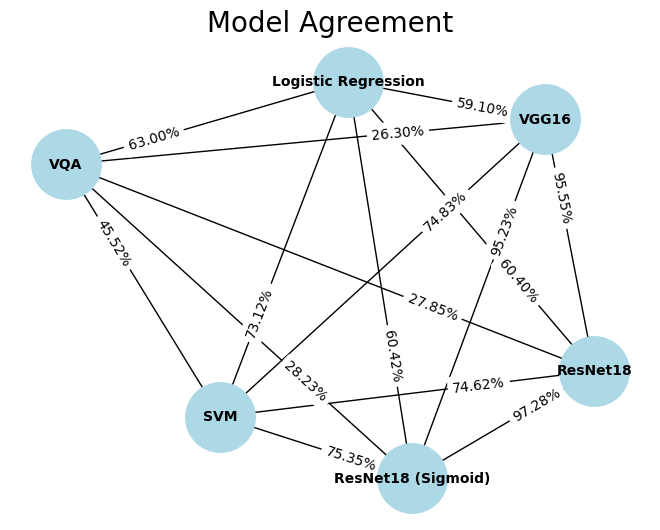

In [68]:
labels = nx.get_edge_attributes(G, 'wperc')
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
pos['SVM'] = (-0.5, -0.5)
pos['VGG16'] = (0.55, 0.5)
nx.draw(G, pos=pos, with_labels=True, node_size=2500, node_color='lightblue', font_size=10, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=labels, label_pos=0.3)
plt.title('Model Agreement', fontsize=20)
plt.show()

In [66]:
pos

{'VGG16': (0.55, 0.5),
 'ResNet18': array([ 0.70837211, -0.34686592]),
 'ResNet18 (Sigmoid)': array([ 0.11920467, -0.70770201]),
 'VQA': array([-1.        ,  0.34839088]),
 'SVM': (-0.5, -0.5),
 'Logistic Regression': array([-0.08670929,  0.62654087])}